# CIFAR‑10 with a Fully Connected Neural Network

**Lab 2: CIFAR‑10 Classification with a Fully Connected Neural Network**

**Weighting (Total 5%)**
- **In‑Lab (3 hours)** — *2%*: train a simple feedforward NN on CIFAR‑10, plot **training vs validation loss/accuracy**, compute a **confusion matrix**, and inspect **misclassifications**.
- **Take‑Home (1 week)** — *3%*: try small modifications (hidden size / activation / LR / epochs), update plots & metrics, and write a short 1–2 page report.

**Learning goals**
- Get comfortable with a new dataset (**CIFAR‑10**, 32×32 color images).
- Practice evaluating models beyond accuracy: curves, confusion matrix, qualitative errors.
- See limits of fully connected NNs on images (CNNs will follow in the next lab).

In [1]:
# ✅ Device setup (CPU/GPU)
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


Importing some required libraries. You can add more if needed.

In [2]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, utils
import numpy as np
import matplotlib.pyplot as plt

## PART A: In lab

1. Load the CIFAR-10 dataset. Load, normalize, create train/val/test splits. The trainset is shown for you.

100%|██████████| 170M/170M [03:57<00:00, 719kB/s]


Train size: 50000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


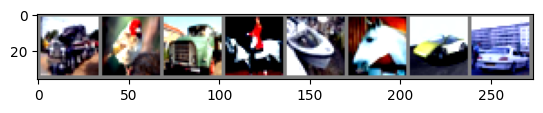

truck bird truck horse ship horse car car


In [3]:
# Transform: convert images to tensors and normalize them
transform = transforms.Compose([
    transforms.ToTensor(),                           # convert to tensor [0,1]
    transforms.Normalize((0.5, 0.5, 0.5),            # mean for R,G,B
                         (0.5, 0.5, 0.5))            # std for R,G,B
])

cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std  = (0.2470, 0.2435, 0.2616)

train_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])


root = './data'
val_size = 5000
batch_size=256

full_train = datasets.CIFAR10(root, train=True, download=True, transform=train_tf)
train_size = len(full_train) - val_size
train_ds, val_ds = random_split(full_train, [train_size, val_size])

# Train DataLoader
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

print("Train size:", len(full_train))


# Class labels
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Helper function to show images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize back to [0,1]
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
imshow(utils.make_grid(images[:8]))
print(' '.join(f'{classes[labels[j]]}' for j in range(8)))


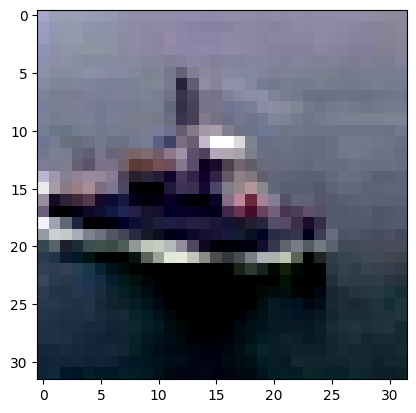

ship
Shape of one class instance:  torch.Size([3, 32, 32])


In [4]:
# Let's see how our data looks into our train set (Not required for the assignment)
img, label = train_ds[4]

imshow(img)
print(classes[label])
print("Shape of one class instance: ", img.shape)

2. Implement a fully connected FFNN (no CNN). Train for a few epochs.


In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Transform: convert images to tensors and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_ds, val_ds = random_split(train_dataset, [train_size, val_size])
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

# Define a simple 3-layer FFNN
class FFNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize model, loss, and optimizer
model = FFNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train for a few epochs
for epoch in range(5):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}: Loss = {total_loss:.2f}, Accuracy = {100 * correct / total:.2f}%")

Epoch 1: Loss = 1161.83, Accuracy = 41.63%
Epoch 2: Loss = 1013.83, Accuracy = 49.08%
Epoch 3: Loss = 937.41, Accuracy = 52.79%
Epoch 4: Loss = 870.26, Accuracy = 56.40%
Epoch 5: Loss = 813.48, Accuracy = 58.88%


3. Plot training vs validation loss and accuracy.


---


---




Epoch 1/5  Train Loss: 0.9040  Train Acc: 67.74%  Val Loss: 1.5217  Val Acc: 52.72%
Epoch 2/5  Train Loss: 0.8214  Train Acc: 70.63%  Val Loss: 1.5615  Val Acc: 53.62%
Epoch 3/5  Train Loss: 0.7467  Train Acc: 73.40%  Val Loss: 1.6890  Val Acc: 53.18%
Epoch 4/5  Train Loss: 0.6924  Train Acc: 75.60%  Val Loss: 1.7035  Val Acc: 51.70%
Epoch 5/5  Train Loss: 0.6251  Train Acc: 77.91%  Val Loss: 1.8149  Val Acc: 52.60%


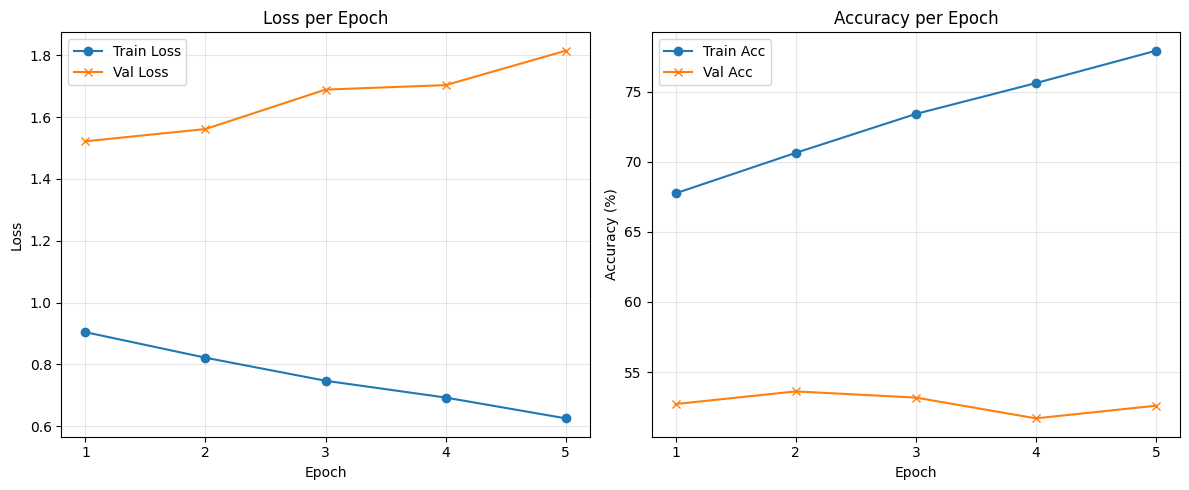

In [19]:
# Run this whole cell (requires model, criterion, optimizer, train_loader, val_ds, device, batch_size)
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc  = 100.0 * correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # validation
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc  = 100.0 * val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs}  Train Loss: {epoch_train_loss:.4f}  Train Acc: {epoch_train_acc:.2f}%  Val Loss: {epoch_val_loss:.4f}  Val Acc: {epoch_val_acc:.2f}%")

# Plot
epochs_range = np.arange(1, len(train_losses) + 1)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses, marker='x', label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, train_accuracies, marker='o', label='Train Acc')
plt.plot(epochs_range, val_accuracies, marker='x', label='Val Acc')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs_range)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

4. Compute a confusion matrix on the validation set.


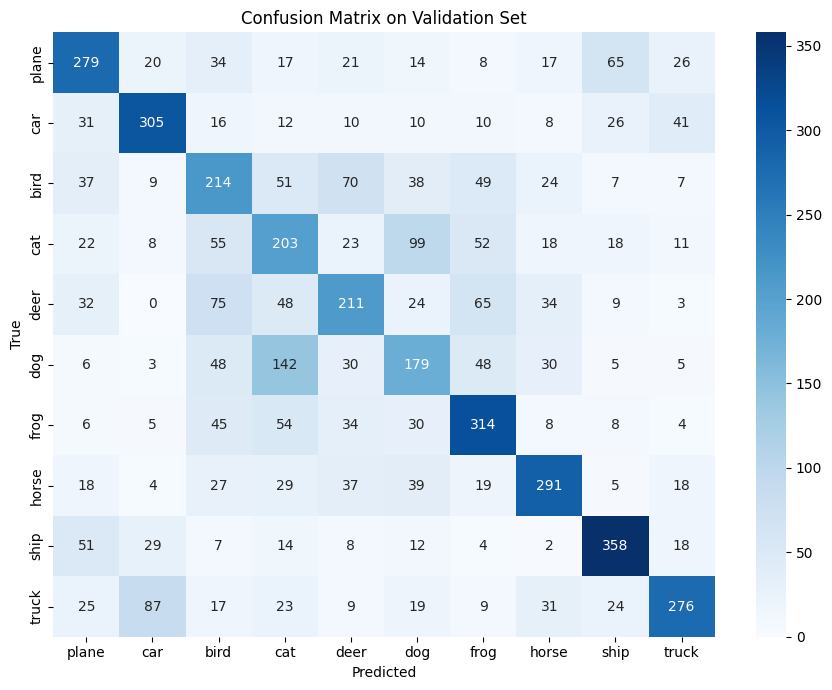

In [20]:
## YOUR CODE GOES HERE
# Compute confusion matrix on the validation set
# Assumes: model, val_ds, device, batch_size, classes are defined
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on Validation Set')
plt.tight_layout()
plt.show()

5. Display a grid of misclassified examples with predicted vs true labels.


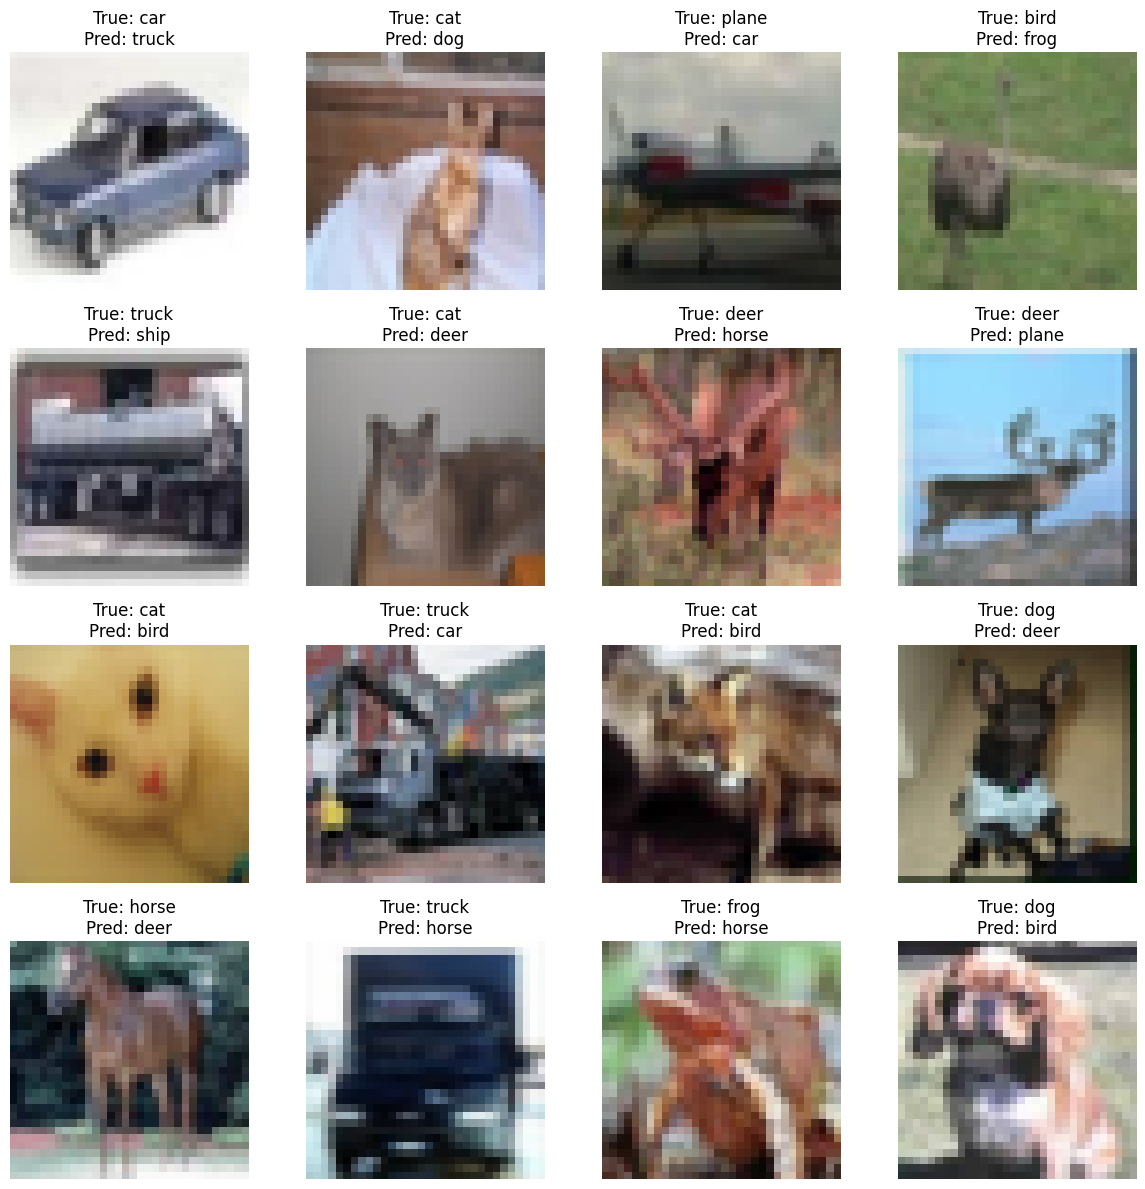

In [21]:
## YOUR CODE GOES HERE
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# Assumes these exist: model, val_ds, device, batch_size, classes, transform used for normalization
# If batch_size not defined, set a reasonable one:
bs = batch_size if 'batch_size' in globals() else 128
val_loader = DataLoader(val_ds, batch_size=bs, shuffle=False)

model.eval()
mis_images = []
mis_true = []
mis_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        mismask = (preds.cpu() != labels)
        if mismask.any():
            imgs_cpu = images.cpu()[mismask].clone()
            for img, t, p in zip(imgs_cpu, labels[mismask], preds.cpu()[mismask]):
                mis_images.append(img)
                mis_true.append(int(t))
                mis_pred.append(int(p))

# Show up to N misclassified images in a grid
N = 16
num = min(N, len(mis_images))
cols = 4
rows = (num + cols - 1) // cols
plt.figure(figsize=(cols*3, rows*3))

# If images were normalized, unnormalize them. Adjust mean/std if different.
mean = np.array([0.5, 0.5, 0.5])   # replace if you used different normalization
std  = np.array([0.5, 0.5, 0.5])   # replace if you used different normalization

for i in range(num):
    img = mis_images[i]
    # img shape: (C, H, W)
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1,2,0))
    npimg = (npimg * std) + mean    # unnormalize
    npimg = np.clip(npimg, 0, 1)

    plt.subplot(rows, cols, i+1)
    plt.imshow(npimg)
    plt.title(f"True: {classes[mis_true[i]]}\nPred: {classes[mis_pred[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## PART B: Take Home

1. Make one or two changes to your hidden size / activation / learning rate / epochs


In [27]:
class FFNN_wide(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = FFNN_wide().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 12

2. Re‑train and update plots & validation metrics.:

---

\

Epoch 1/12  Train Loss: 1.6639  Train Acc: 40.74%  Val Loss: 1.5932  Val Acc: 42.96%
Epoch 2/12  Train Loss: 1.4592  Train Acc: 48.29%  Val Loss: 1.4789  Val Acc: 48.66%
Epoch 3/12  Train Loss: 1.3446  Train Acc: 52.18%  Val Loss: 1.4328  Val Acc: 50.36%
Epoch 4/12  Train Loss: 1.2506  Train Acc: 55.65%  Val Loss: 1.4027  Val Acc: 51.94%
Epoch 5/12  Train Loss: 1.1676  Train Acc: 58.56%  Val Loss: 1.4064  Val Acc: 51.88%
Epoch 6/12  Train Loss: 1.0785  Train Acc: 61.82%  Val Loss: 1.4210  Val Acc: 52.62%
Epoch 7/12  Train Loss: 0.9998  Train Acc: 64.22%  Val Loss: 1.4500  Val Acc: 52.52%
Epoch 8/12  Train Loss: 0.9137  Train Acc: 67.36%  Val Loss: 1.4878  Val Acc: 51.54%
Epoch 9/12  Train Loss: 0.8419  Train Acc: 70.32%  Val Loss: 1.6021  Val Acc: 52.70%
Epoch 10/12  Train Loss: 0.7640  Train Acc: 72.76%  Val Loss: 1.6027  Val Acc: 53.24%
Epoch 11/12  Train Loss: 0.7020  Train Acc: 75.02%  Val Loss: 1.6867  Val Acc: 52.92%
Epoch 12/12  Train Loss: 0.6483  Train Acc: 77.05%  Val Loss: 1

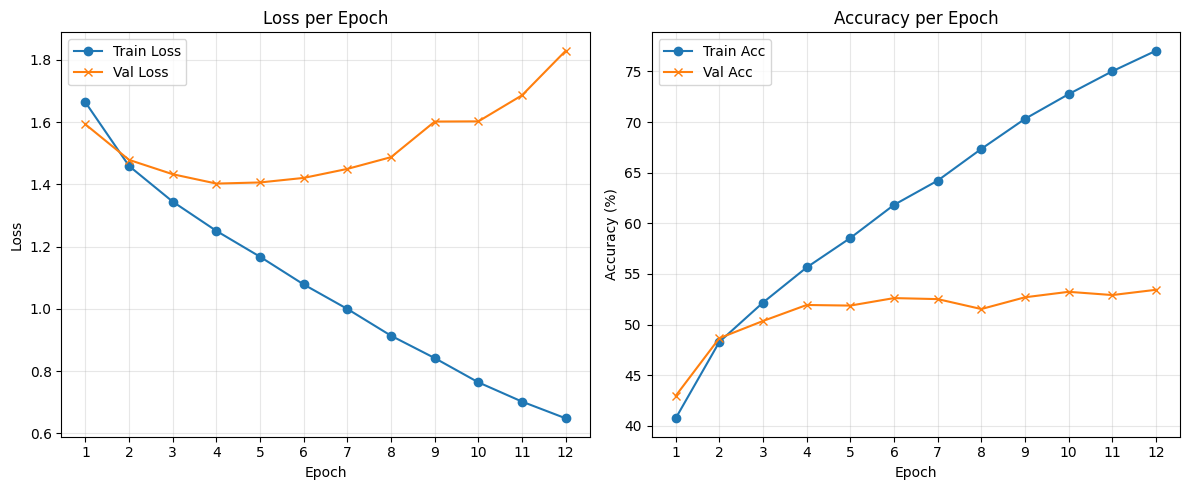

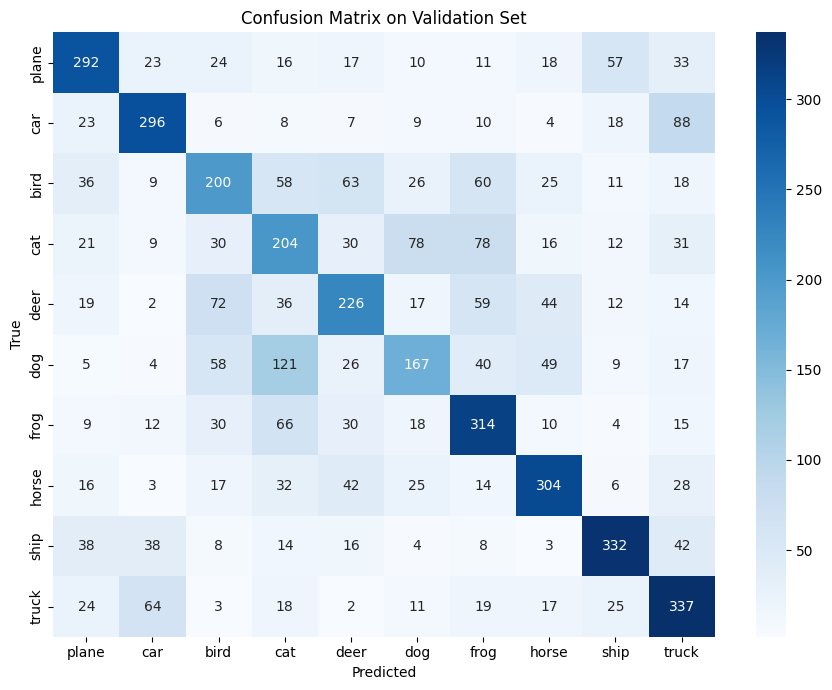

Best Val Accuracy during run: 53.44%


In [28]:
# Retrain, plot metrics, and show confusion matrix (NO misclassified grid)
# Requires already-defined: model, optimizer, criterion, train_loader, val_ds, device, batch_size, classes, epochs
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import torch

# Safety defaults if missing
if 'batch_size' not in globals():
    batch_size = 128
if 'classes' not in globals():
    classes = [str(i) for i in range(10)]

val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_acc = 0.0
best_state = None

# Training + validation loop
for epoch in range(1, epochs + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = 100.0 * correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # Validation
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = 100.0 * val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch}/{epochs}  Train Loss: {epoch_train_loss:.4f}  Train Acc: {epoch_train_acc:.2f}%  Val Loss: {epoch_val_loss:.4f}  Val Acc: {epoch_val_acc:.2f}%")

# Plot training vs validation loss and accuracy
epochs_range = np.arange(1, len(train_losses) + 1)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses,   marker='x', label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.xticks(epochs_range); plt.grid(alpha=0.3); plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, train_accuracies, marker='o', label='Train Acc')
plt.plot(epochs_range, val_accuracies,   marker='x', label='Val Acc')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.xticks(epochs_range); plt.grid(alpha=0.3); plt.legend()

plt.tight_layout()
plt.show()

# Confusion matrix (validation)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix on Validation Set'); plt.tight_layout(); plt.show()

print(f"Best Val Accuracy during run: {best_val_acc:.2f}%")
# Optionally restore best model weights:
# if best_state is not None:
#     model.load_state_dict(best_state)

3. Write a 1–2 page PDF discussing training dynamics, confusion trends, and effect of your changes. DONT FORGET TO SUBMIT PDF.